# Heart Disease Data Analysis

**Final Portfolio Project** — Codecademy Data Analyst Career Path

This project explores a heart disease dataset to identify key factors associated with the presence of heart disease. The goal is to understand which clinical and demographic variables show the strongest relationships with heart disease through exploratory data analysis and visualization.

## Project Goals

- Load and inspect the heart disease dataset
- Clean and prepare the data for analysis
- Perform exploratory data analysis using summary statistics and visualizations
- Identify which factors are most strongly associated with heart disease
- Communicate findings clearly through data visualizations and narrative

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (relative path)
df = pd.read_csv("heart_data/heart.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Data Overview

The dataset contains **918 patients** with **12 variables**. The target variable is `HeartDisease` (1 = has heart disease, 0 = no heart disease).

We will explore how factors like age, cholesterol, maximum heart rate, chest pain type, and others relate to heart disease.

In [11]:
# Basic information about the dataset
print("=== Data Types and Non-Null Counts ===")
df.info()

print("\n=== First 10 rows ===")
print(df.head(10))

print("\n=== Summary Statistics ===")
df.describe()

=== Data Types and Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB

=== First 10 rows ===
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Number of duplicate rows: 0


## Data Cleaning

The dataset appears to be quite clean:
- No missing values
- No duplicate rows

We will proceed with exploratory analysis. If needed, we can handle any outliers or inconsistent values during EDA.

/var/folders/sz/sspf0y995495xq1h9gp43k480000gn/T/ipykernel_25180/2680633435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='HeartDisease', palette='Set2')


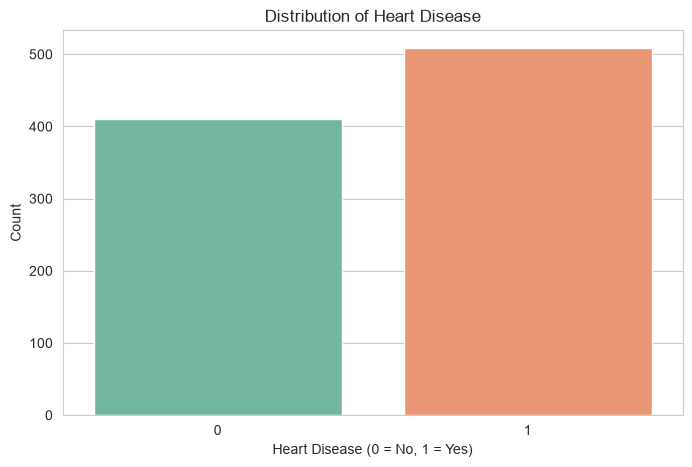

Heart Disease distribution:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [4]:
# Distribution of Heart Disease
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='HeartDisease', palette='Set2')
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print("Heart Disease distribution:")
print(df['HeartDisease'].value_counts(normalize=True) * 100)

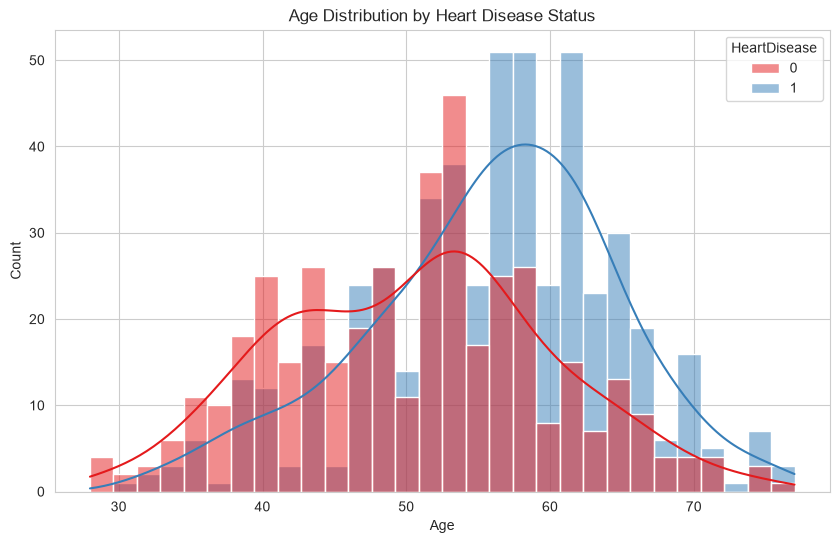

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='HeartDisease', bins=30, kde=True, palette='Set1')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

/var/folders/sz/sspf0y995495xq1h9gp43k480000gn/T/ipykernel_25180/3612130123.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[i], palette='Set2')
/var/folders/sz/sspf0y995495xq1h9gp43k480000gn/T/ipykernel_25180/3612130123.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[i], palette='Set2')
/var/folders/sz/sspf0y995495xq1h9gp43k480000gn/T/ipykernel_25180/3612130123.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, ax=ax

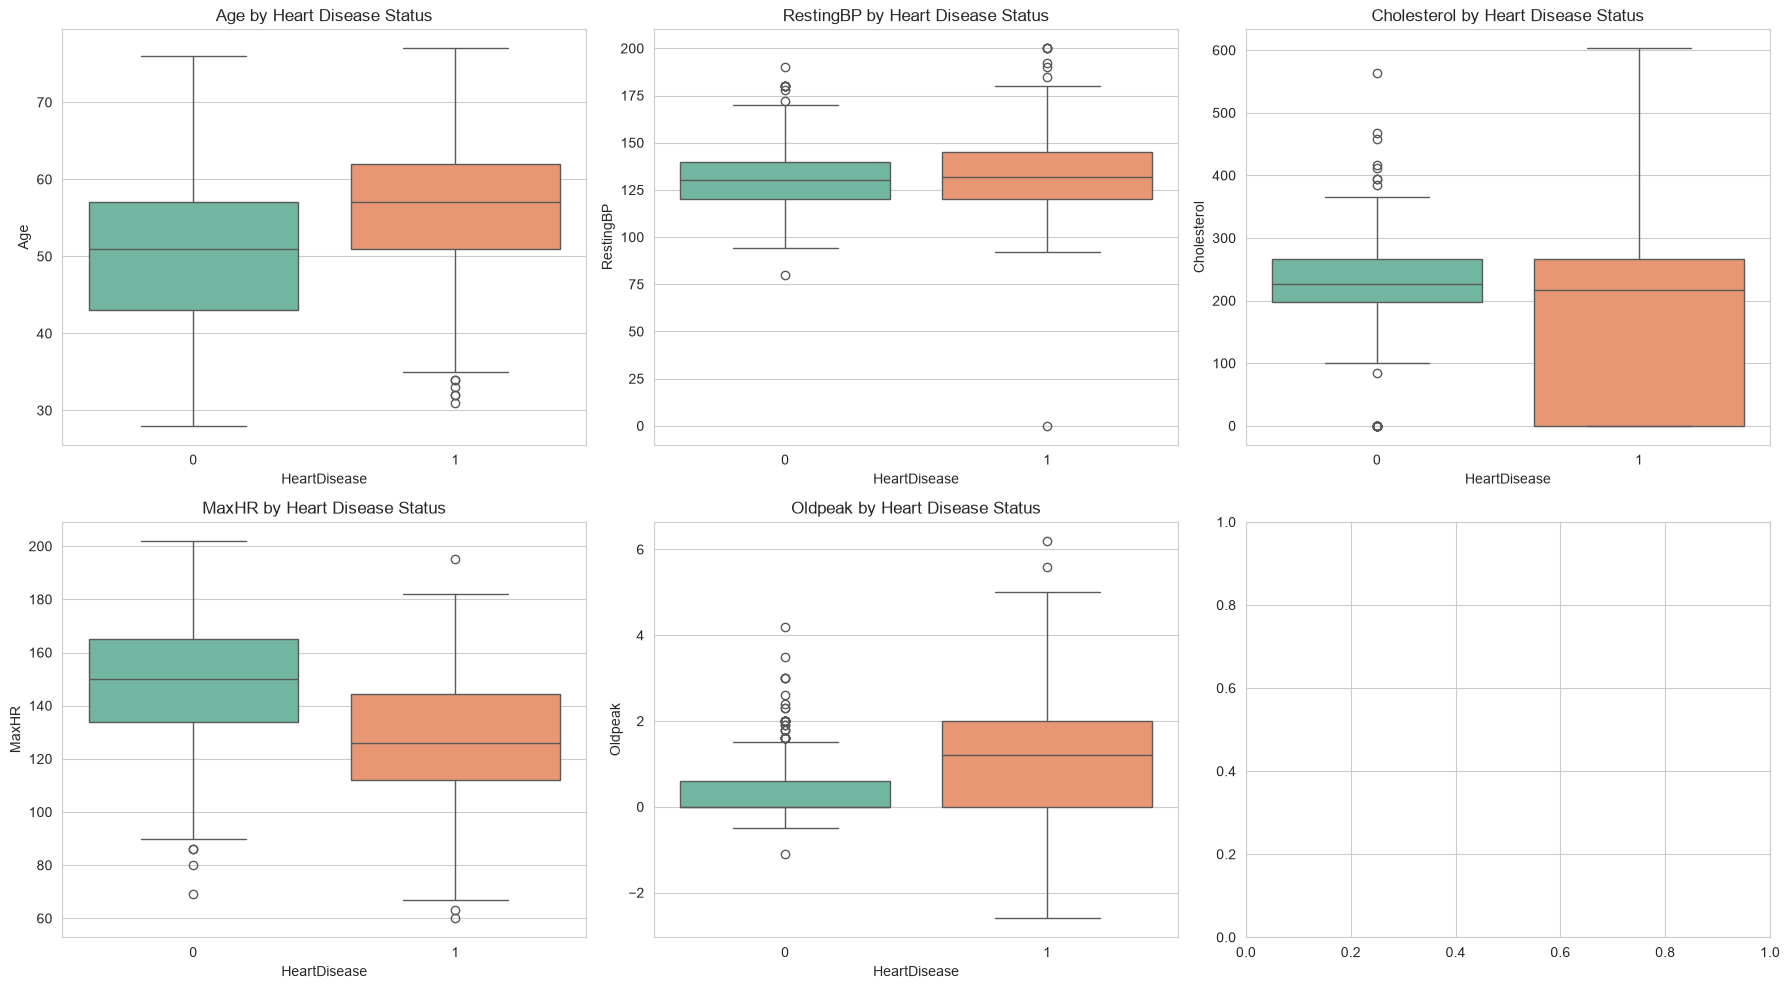

In [6]:
# Compare key numerical features
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Heart Disease Status')

plt.tight_layout()
plt.show()

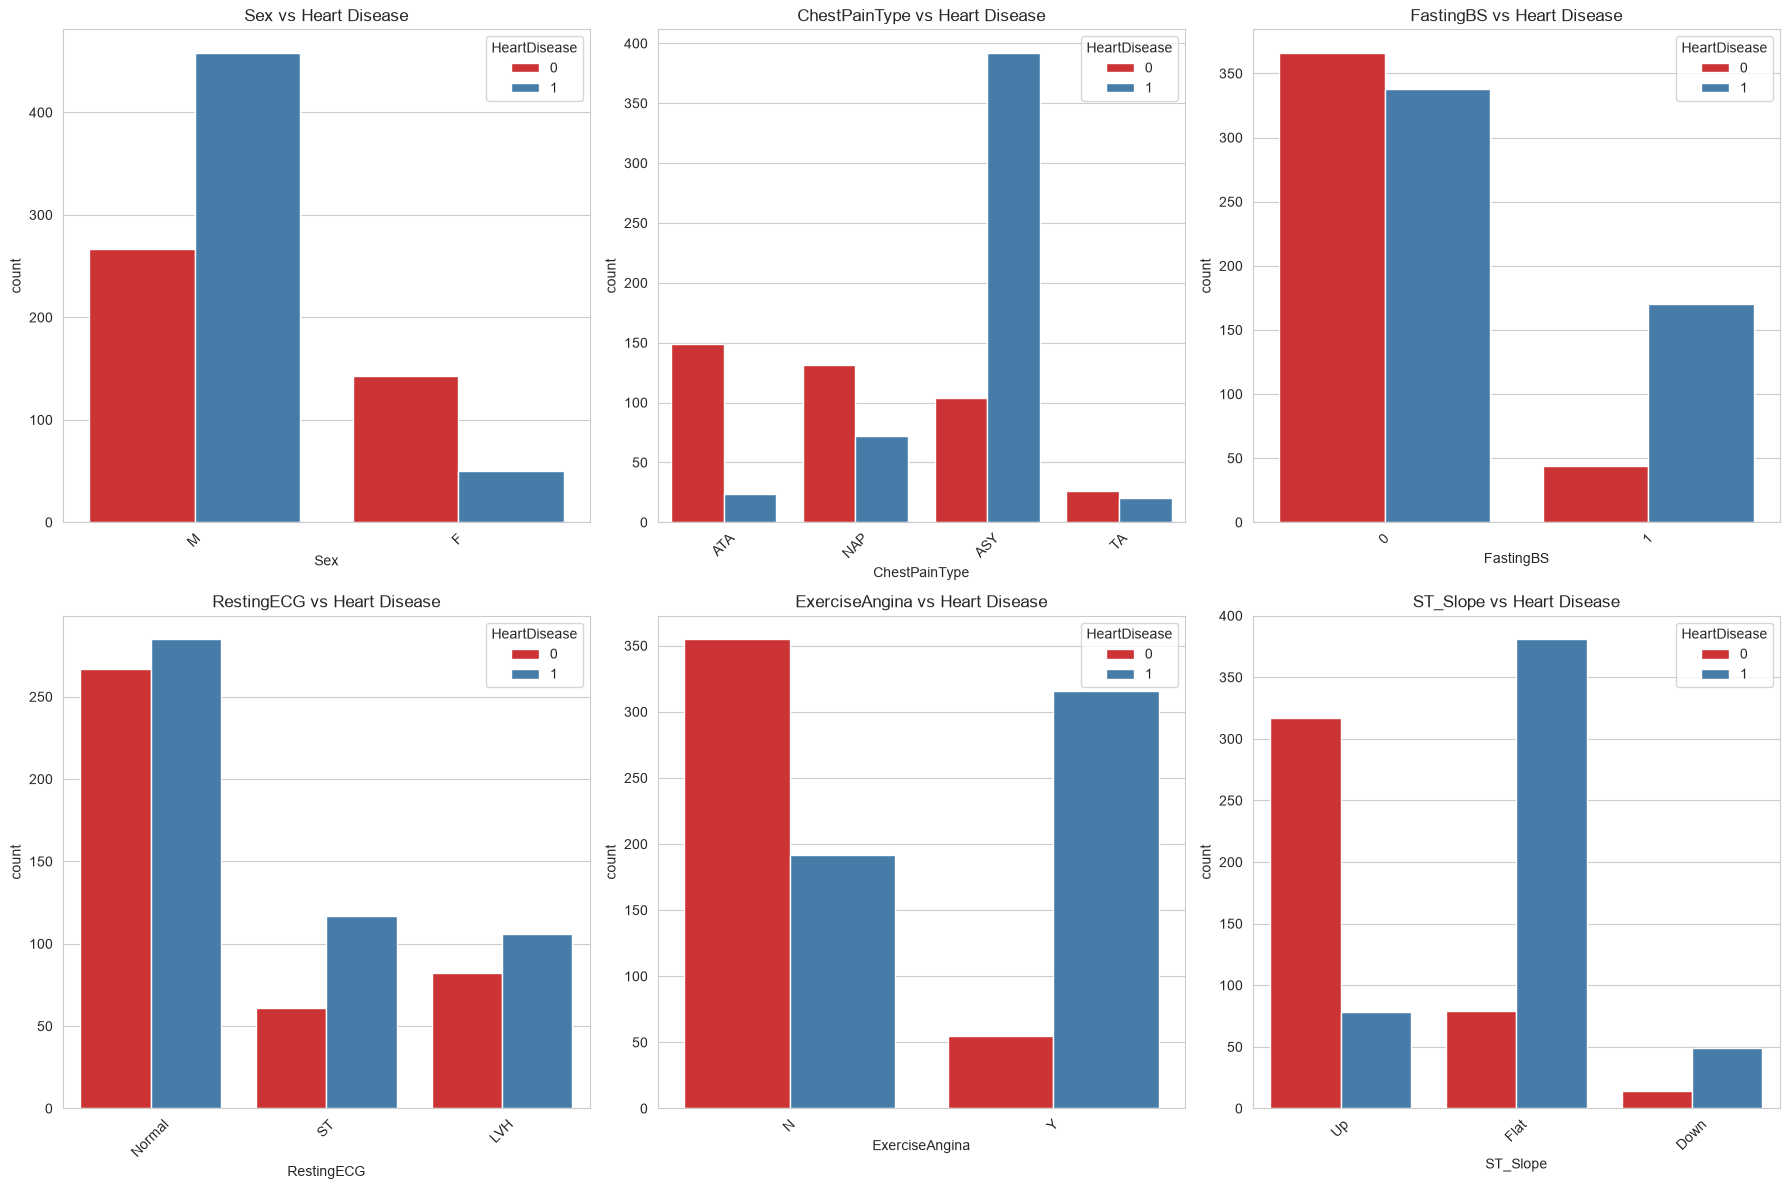

In [7]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} vs Heart Disease')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

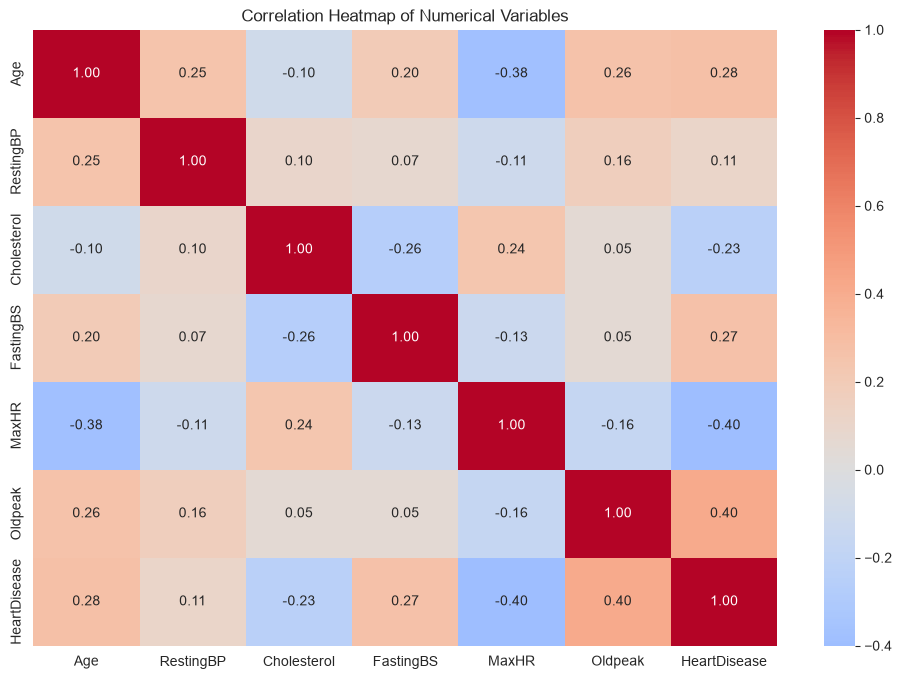

In [8]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## Key Insights from EDA

**Strong relationships observed:**
- **Age**: Older patients have higher rates of heart disease.
- **MaxHR (Maximum Heart Rate)**: Lower maximum heart rate is associated with heart disease.
- **Oldpeak**: Higher ST depression values are linked to heart disease.
- **Chest Pain Type**: Certain types (especially ASY) show much higher heart disease rates.
- **ExerciseAngina**: Patients with exercise-induced angina have significantly higher heart disease prevalence.
- **ST_Slope**: Flat or downsloping ST segments are strongly associated with heart disease.

Cholesterol and Resting Blood Pressure show weaker direct relationships in this dataset.

## Conclusion

Through exploratory data analysis, we identified several factors strongly associated with heart disease:

- **Age** and **Maximum Heart Rate** are important indicators.
- **Exercise-induced angina** and **ST_Slope** appear to be particularly strong predictors.
- Certain **chest pain types** (especially asymptomatic) correlate with higher heart disease rates.

### Key Takeaways:
- Heart disease risk increases with age and is higher in males.
- Lower maximum heart rate and higher Oldpeak values are warning signs.
- The combination of clinical symptoms (ExerciseAngina, ChestPainType, ST_Slope) provides strong signals.

This analysis demonstrates how data exploration and visualization can uncover meaningful patterns in medical data that could support early risk identification.

**Skills Demonstrated**: Data loading, cleaning, exploratory analysis, statistical visualization, and communicating insights through clear narratives and charts.